In [136]:
#Setup: imports, style, statistical helpers, plot helpers, constants ────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from soft_style import (
    configure_style, figure_title, panel_subtitle, save_figure,
    LINE_PALETTE, BAR_PALETTE, MULTILINE_PALETTE,
    CMAP_SEQUENTIAL, CMAP_SEQUENTIAL_BLUE, CMAP_DIVERGING, NEUTRAL,
)
configure_style()

C_G,  C_G_dark = LINE_PALETTE["blue"],   "#1A5B81"   # soft blue — Generator
C_L,  C_L_dark = BAR_PALETTE["coral"],   "#8B1515"   # warm coral — Load

# 3-level sweep colours (light → dark), shared by all sensitivity line plots
COLORS_S = [MULTILINE_PALETTE["teal"], LINE_PALETTE["blue"], "#1A5B81"]  # #28AAAA → #2878CC → #1A5B81
COLORS_M = [BAR_PALETTE["peach"],      BAR_PALETTE["coral"], "#8B1515"]  # #EF8F8F → #CC2929 → #8B1515

# Scalar parameters
A_G_FIXED  = 0.5
CVAR_ALPHA = 0.05
_AL_TICKS  = np.linspace(0, 1, 11)
AG_TARGETS = [0.25, 0.50, 0.75]
AG_LABELS  = [r"0.25", "0.50", r"0.75"]

BASE      = "sensitivity/default_baseload_risk_aversion"
BASE_PAP  = "sensitivity/default_pap_risk_aversion"
PROB_PATH = ("../data/processed/scenarios_reduced_2000/"
             "probabilities_scenarios_reduced_20y_2000s.csv")


def _wq(values: np.ndarray, weights: np.ndarray, q: float) -> float:
    """Weighted quantile via sorted cumulative-weight interpolation."""
    sorter = np.argsort(values)
    sv, sw = values[sorter], weights[sorter]
    sw = sw / sw.sum()
    return float(np.interp(q, np.cumsum(sw), sv))


def _wcvar(values: np.ndarray, weights: np.ndarray, alpha: float) -> float:
    """Weighted CVaR (Expected Shortfall) at level alpha."""
    q = _wq(values, weights, alpha)
    mask = values <= q
    w_tail = weights[mask]
    return float(np.average(values[mask], weights=w_tail)) if w_tail.sum() > 0 else np.nan


def summarise(df_raw: pd.DataFrame, probs: np.ndarray,
              A_G_fixed: float = A_G_FIXED,
              alpha: float = CVAR_ALPHA) -> pd.DataFrame:
    """For each A_L column (at A_G ≈ A_G_fixed), compute weighted statistics.

    Returns a DataFrame: A_L | mean | q05 | q10 | q90 | q95 | cvar
    """
    ag_vals = df_raw.columns.get_level_values(0).astype(float)
    sub     = df_raw.loc[:, np.isclose(ag_vals, A_G_fixed)]
    al_vals = sub.columns.get_level_values(1).astype(float)
    records = []
    for col, al in zip(sub.columns, al_vals):
        v = sub[col].values.astype(float)
        records.append({
            "A_L":  al,
            "mean": float(np.average(v, weights=probs)),
            "q05":  _wq(v, probs, 0.05),
            "q10":  _wq(v, probs, 0.10),
            "q90":  _wq(v, probs, 0.90),
            "q95":  _wq(v, probs, 0.95),
            "cvar": _wcvar(v, probs, alpha),
        })
    return pd.DataFrame(records).sort_values("A_L").reset_index(drop=True)


# ── Plot helpers ───────────────────────────────────────────────────────────────
def _style_panel(ax, title: str) -> None:
    """Apply consistent styling to one earnings panel."""
    panel_subtitle(ax, title)
    ax.set_ylabel("Earnings [M€]")
    ax.legend(loc="best")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
def _style_panel_size(ax, title: str) -> None:
    """Apply consistent styling to one earnings panel."""
    panel_subtitle(ax, title)
    ax.set_ylabel("Strike Price $S$ [EUR/MWh]")
    ax.legend(loc="best")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))


def plot_risk_profile(fig, axes, summ_G, summ_L, summ_nc_G, summ_nc_L,
                      mode: str = "bands",
                      contract_label: str = "contract") -> None:
    """Render a 2-panel risk-profile figure (Generator top, Load bottom).

    mode = "bands"  stacked percentile bands (5—95 outer, 10—90 inner) + mean
    mode = "cvar"   mean vs CVaR with shaded gap
    """
    alpha_pct = int(CVAR_ALPHA * 100)
    for ax, summ, summ_nc, C, Cd, label in [
        (axes[0], summ_G, summ_nc_G, C_G, C_G_dark, "Generator"),
        (axes[1], summ_L, summ_nc_L, C_L, C_L_dark, "Load"),
    ]:
        x = summ["A_L"].values
        if mode == "bands":
            ax.fill_between(x, summ["q05"], summ["q95"],
                            color=C, alpha=0.10, label="5th-95th pct.")
            ax.fill_between(x, summ["q10"], summ["q90"],
                            color=C, alpha=0.20, label="10th-90th pct.")
            ax.plot(x, summ["mean"],
                    color=C, lw=2.0, label=f"Expected Value")
           # ax.plot(x, summ_nc["mean"],
            #        color=Cd, lw=1.5, ls="--",
            #        label=f"{label} no-contract — mean")
            ax.plot(x, summ_nc["cvar"],
                    color=Cd, lw=1.5, ls="-.",
                    label=f"Disagreement -CVaR")
        else:  # "cvar"
            ax.fill_between(x, summ["cvar"], summ["mean"],
                            color=C, alpha=0.15)#, label="Mean—CVaR gap")
            ax.plot(x, summ["mean"],
                    color=C, lw=2.0, label=f"Expected Value")
            ax.plot(x, summ["cvar"],
                    color=C, lw=1.5, ls=":",
                    label=f"Contract - CVaR")
            #ax.plot(x, summ_nc["mean"],
            #        color=Cd, lw=1.5, ls="--", label="Mean (no contract)")
            ax.plot(x, summ_nc["cvar"],
                    color=Cd, lw=1.0, ls="-.",
                    label=f"Disagreement - CVaR")
        _style_panel(ax, f"{label}  |  $A_G$ = {A_G_FIXED}")

    axes[0].set_xlabel("Load Risk Aversion ($A_L$)")
    axes[0].set_xticks(_AL_TICKS)
    axes[1].set_xlabel("Load Risk Aversion ($A_L$)")
    axes[1].set_xticks(_AL_TICKS)
    plt.tight_layout()


def save_panels(fig, axes_list, fnames, dpi=300, padding=0.12):
    """Save each axis from a multi-panel figure as a standalone PNG.

    Handles colorbars created via make_axes_locatable: any axes that is
    horizontally adjacent to ax (within 50 display px) and vertically
    overlapping is merged into the bounding box before saving.

    Args:
        fig:        The parent Figure.
        axes_list:  Iterable of Axes objects (e.g. axes, axes.flat).
        fnames:     Iterable of output file name stems (no extension).
        dpi:        Output resolution.
        padding:    Extra margin added around each panel, in inches.
    """
    import os
    from matplotlib.transforms import Bbox
    axes_list = list(axes_list)   # materialize: callers may pass axes.flat (one-shot)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bg = fig.get_facecolor()
    for ax, fname in zip(axes_list, fnames):
        bbox = ax.get_tightbbox(renderer)
        # Absorb colorbar / divider axes that sit immediately to the right
        for other in fig.axes:
            if other is ax or any(other is p for p in axes_list):
                continue
            ob = other.get_tightbbox(renderer)
            if ob is None:
                continue
            h_adjacent = 0 <= (ob.x0 - bbox.x1) < 50   # within 50 display px
            v_overlap  = ob.y0 < bbox.y1 and ob.y1 > bbox.y0
            if h_adjacent and v_overlap:
                bbox = Bbox.union([bbox, ob])
        bbox_in = bbox.transformed(fig.dpi_scale_trans.inverted()).padded(padding)
        os.makedirs(os.path.dirname(fname) or ".", exist_ok=True)
        fig.savefig(f"{fname}.png", dpi=dpi, bbox_inches=bbox_in, facecolor=bg)
        print(f"Saved {fname}.png")


def plot_contract_params_grid(fig, axes, df_row0, df_row1, row_configs):
    """Render a 2×2 contract-parameter figure: heatmap + A_G slices for two metrics.

    Parameters
    ----------
    fig        : matplotlib Figure (needed for colorbar creation)
    axes       : 2×2 array of Axes from plt.subplots(2, 2, ...)
    df_row0    : DataFrame for the top row    (index = A_G, columns = A_L)
    df_row1    : DataFrame for the bottom row (index = A_G, columns = A_L)
    row_configs: list of 2 dicts, one per row, each with keys:
                   heatmap_label  – colorbar label
                   heatmap_panel  – panel subtitle for the heatmap axis
                   slice_label    – y-axis label for the slice-line axis
                   slice_panel    – panel subtitle for the slice-line axis
                   cmap           – colormap for pcolormesh
                   colors         – 3-element list of line colors for A_G slices
    """
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    fig.subplots_adjust(hspace=0.45, wspace=0.45)

    for row_idx, (df, cfg) in enumerate(zip([df_row0, df_row1], row_configs)):
        ag_vals = df.index.astype(float).values
        al_vals = df.columns.astype(float).values
        AL_mesh, AG_mesh = np.meshgrid(al_vals, ag_vals)
        ag_idxs = [int(np.argmin(np.abs(ag_vals - t))) for t in AG_TARGETS]

        # Heatmap panel
        ax_heat = axes[row_idx, 0]
        pcm = ax_heat.pcolormesh(AL_mesh, AG_mesh, df.values, cmap=cfg["cmap"], shading="nearest")
        divider = make_axes_locatable(ax_heat)
        cax = divider.append_axes("right", size="5%", pad=0.08)
        cb = fig.colorbar(pcm, cax=cax)
        cb.set_label(cfg["heatmap_label"], color=NEUTRAL["label"])
        cb.ax.tick_params(colors=NEUTRAL["tick"], labelsize=8)
        cb.outline.set_edgecolor(NEUTRAL["spine"])
        cb.outline.set_linewidth(0.6)
        ax_heat.set_xticks(_AL_TICKS)
        ax_heat.set_xlabel("Load Risk Aversion ($A_L$)")
        ax_heat.set_ylabel("Generator Risk Aversion ($A_G$)")
        panel_subtitle(ax_heat, cfg["heatmap_panel"])

        # Slice-line panel
        ax_slice = axes[row_idx, 1]
        for idx, color, lbl in zip(ag_idxs, cfg["colors"], AG_LABELS):
            ax_slice.plot(al_vals, df.round(4).iloc[idx].values,
                          color=color, linewidth=1.8,
                          marker="o", markersize=5,
                          markeredgecolor="white", markeredgewidth=0.8,
                          label=f"$A_G$ = {lbl}")
        ax_slice.set_xticks(_AL_TICKS)
        ax_slice.set_xlabel("Load Risk Aversion ($A_L$)")
        ax_slice.set_ylabel(cfg["slice_label"])
        panel_subtitle(ax_slice, cfg["slice_panel"])
        ax_slice.legend(loc="best")

In [137]:
# plot_risk_profile — updated to accept optional Nash disagreement-point overlay
def plot_risk_profile(fig, axes, summ_G, summ_L, summ_nc_G, summ_nc_L,
                      mode: str = "bands",
                      contract_label: str = "contract",
                      disagree_G=None, disagree_L=None) -> None:
    """Render a 2-panel risk-profile figure (Generator top, Load bottom).

    mode = "bands"  stacked percentile bands (5-95 outer, 10-90 inner) + mean
    mode = "cvar"   mean vs CVaR with shaded gap
    disagree_G/L    optional 1-D arrays of Nash disagreement values (one per A_L)
    """
    alpha_pct = int(CVAR_ALPHA * 100)
    for ax, summ, summ_nc, C, Cd, label, disagree in [
        (axes[0], summ_G, summ_nc_G, C_G, C_G_dark, "Generator", disagree_G),
        (axes[1], summ_L, summ_nc_L, C_L, C_L_dark, "Load", disagree_L),
    ]:
        x = summ["A_L"].values
        if mode == "bands":
            ax.fill_between(x, summ["q05"], summ["q95"],
                            color=C, alpha=0.10, label="5th-95th pct.")
            ax.fill_between(x, summ["q10"], summ["q90"],
                            color=C, alpha=0.20, label="10th-90th pct.")
            ax.plot(x, summ["mean"],
                    color=C, lw=2.0, label="Expected Value")
           # ax.plot(x, summ_nc["mean"],
            #        color=Cd, lw=1.5, ls="--",
            #        label=f"{label} no-contract — mean")
            #ax.plot(x, summ_nc["cvar"],
            #        color=Cd, lw=1.5, ls="-.",
            #        label="Disagreement -CVaR")
        else:  # "cvar"
            ax.fill_between(x, summ["cvar"], summ["mean"],
                            color=C, alpha=0.15)
            ax.plot(x, summ["mean"],
                    color=C, lw=2.0, label="Expected Value")
            ax.plot(x, summ["cvar"],
                    color=C, lw=1.5, ls=":",
                    label="Contract - CVaR")
            #ax.plot(x, summ_nc["mean"],
            #        color=Cd, lw=1.5, ls="--", label="Mean (no contract)")
            #ax.plot(x, summ_nc["cvar"],
            #        color=Cd, lw=1.0, ls="-.",
            #        label="Disagreement - CVaR")
        _style_panel(ax, f"{label}  |  $A_G$ = {A_G_FIXED}")
        if label == "Load":
            ax.legend(loc="upper right")  # "best" lands awkwardly mid-panel here

    axes[0].set_xlabel("Load Risk Aversion ($A_L$)")
    axes[0].set_xticks(_AL_TICKS)
    axes[1].set_xlabel("Load Risk Aversion ($A_L$)")
    axes[1].set_xticks(_AL_TICKS)
    plt.tight_layout()

In [138]:
# ── Scenario input summary statistics ────────────────────────────────────────
# Probability-weighted mean and std for price, production, and capture rate,
# collapsed to per-scenario annual means then aggregated across scenarios.
# No dependency on BASE or any earlier cell.

SCEN_PATH = "../data/processed/scenarios_reduced_2000"
_YEARS, _N = 20, 2000

def _read_scen(kind):
    return pd.read_csv(
        f"{SCEN_PATH}/{kind}_scenarios_reduced_{_YEARS}y_{_N}s.csv",
        index_col=0,
    ).to_numpy()

_price = _read_scen("price")        # (20, 2000)  kEUR/MWh
_prod  = _read_scen("production")   # (20, 2000)  GWh/year
_cr    = _read_scen("capture_rate") # (20, 2000)  dimensionless

_prob  = pd.read_csv(
    f"{SCEN_PATH}/probabilities_scenarios_reduced_{_YEARS}y_{_N}s.csv"
)["Probability"].to_numpy()
_prob  = _prob / _prob.sum()

def _wt_mean_std(X, prob):
    """Probability-weighted mean and std of per-scenario annual means."""
    xs  = X.mean(axis=0)                    # annual mean per scenario, shape (S,)
    mu  = float((prob * xs).sum())
    sig = float(np.sqrt((prob * (xs - mu) ** 2).sum()))
    return mu, sig

rows = {
    "Price [EUR/MWh]":     _wt_mean_std(_price * 1e3,        _prob),  # kEUR/MWh -> EUR/MWh
    "Production [GWh/yr]": _wt_mean_std(_prod,               _prob),
    "Production [MW]":     _wt_mean_std(_prod * 1e3 / 8760,  _prob),  # GWh/yr -> MW
    "Capture rate":        _wt_mean_std(_cr,                 _prob),
}

summary = (
    pd.DataFrame(rows, index=["Mean", "Std"])
    .T
    .round(2)
)

display(summary)
summary.to_csv("scenario_summary_stats.csv")
print("Saved -> scenario_summary_stats.csv")

,Mean,Std
Price [EUR/MWh],118.12,10.00
Production [GWh/yr],98.71,1.60
Production [MW],11.27,0.18
Capture rate,0.58,0.02


Saved -> scenario_summary_stats.csv


In [139]:
#Data loading 
probs = pd.read_csv(PROB_PATH).values.flatten()
probs = probs / probs.sum()

def _load(base: str, fname: str) -> pd.DataFrame:
    return pd.read_csv(f"{base}/{fname}", header=[0, 1], index_col=0)

# Baseload contract
sum_G    = summarise(_load(BASE, "earnings_G.csv"),    probs)
sum_L    = summarise(_load(BASE, "earnings_L.csv"),    probs)
sum_nc_G = summarise(_load(BASE, "earnings_nc_G.csv"), probs)
sum_nc_L = summarise(_load(BASE, "earnings_nc_L.csv"), probs)

# Pay-as-produced (PAP) contract
sum_pap_G    = summarise(_load(BASE_PAP, "earnings_G.csv"),    probs)
sum_pap_L    = summarise(_load(BASE_PAP, "earnings_L.csv"),    probs)
sum_pap_nc_G = summarise(_load(BASE_PAP, "earnings_nc_G.csv"), probs)
sum_pap_nc_L = summarise(_load(BASE_PAP, "earnings_nc_L.csv"), probs)

# Disagreement points from model grid
def _load_disagree(base: str, party: str) -> np.ndarray:
    """Load grid_disagreement_G/L, extract row at A_G_FIXED, return 1-D array."""
    df = pd.read_csv(f"{base}/grid_disagreement_{party}.csv", index_col=0)
    df.index = df.index.astype(float)
    ag_idx = int(np.argmin(np.abs(df.index.values - A_G_FIXED)))
    return df.iloc[ag_idx].values

dg_G     = _load_disagree(BASE,     "G")
dg_L     = _load_disagree(BASE,     "L")
dg_pap_G = _load_disagree(BASE_PAP, "G")
dg_pap_L = _load_disagree(BASE_PAP, "L")

alpha_pct = int(CVAR_ALPHA * 100)
print(f"Loaded {len(sum_G)} A_L values. "
      f"CVaR{alpha_pct} range (G): [{sum_G['cvar'].min():.1f}, {sum_G['cvar'].max():.1f}] M€")

Loaded 15 A_L values. CVaR5 range (G): [120.9, 128.4] M€


---
## Baseload contract
*Run the setup cell and data cell first.*

Saved plots/baseload_earnings/baseload_earnings_stacked_bands.png
Saved plots/baseload_earnings/baseload_earnings_stacked_bands_G.png
Saved plots/baseload_earnings/baseload_earnings_stacked_bands_L.png


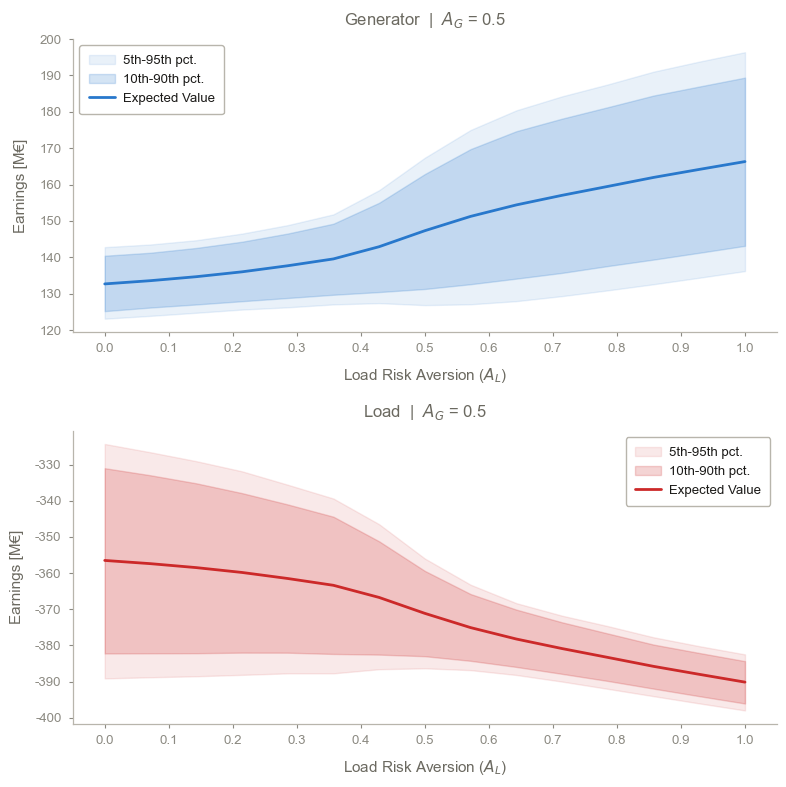

In [140]:
#Baseload: stacked percentile bands 
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=False)
fig.subplots_adjust(hspace=0.12, top=0.88)
plot_risk_profile(fig, axes, sum_G, sum_L, sum_nc_G, sum_nc_L, mode="bands",
                  disagree_G=dg_G, disagree_L=dg_L)
#figure_title(fig, f"Stacked percentile bands  ($A_G$ = {A_G_FIXED} fixed)")
save_figure(fig, "plots/baseload_earnings/baseload_earnings_stacked_bands")
save_panels(fig, axes, ["plots/baseload_earnings/baseload_earnings_stacked_bands_G",
                        "plots/baseload_earnings/baseload_earnings_stacked_bands_L"])
plt.show()

Saved plots/baseload_earnings/baseload_earnings_cvar5_lineplot.png
Saved plots/baseload_earnings/baseload_earnings_cvar5_lineplot_G.png
Saved plots/baseload_earnings/baseload_earnings_cvar5_lineplot_L.png


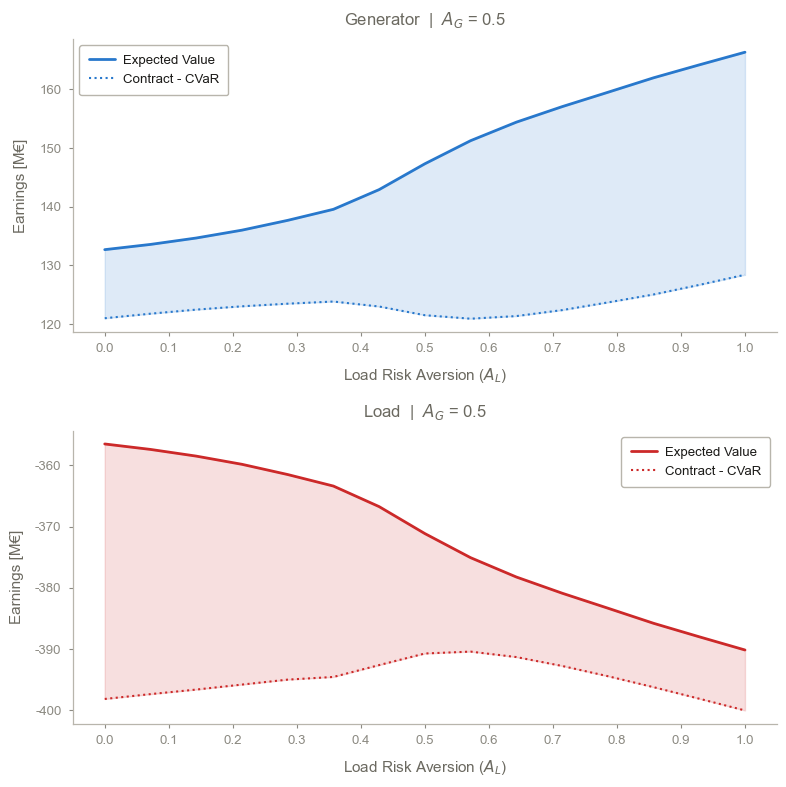

In [141]:
# ── Baseload: CVaR vs mean
# CVaR_α = expected earnings in the worst α% of scenarios (left tail).
# Shaded gap between mean and CVaR visualises the downside risk exposure.
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=False)
fig.subplots_adjust( top=0.88)
plot_risk_profile(fig, axes, sum_G, sum_L, sum_nc_G, sum_nc_L, mode="cvar",
                  disagree_G=dg_G, disagree_L=dg_L)
#figure_title(fig, f"CVaR{alpha_pct} vs mean earnings  ($A_G$ = {A_G_FIXED} fixed)")
save_figure(fig, f"plots/baseload_earnings/baseload_earnings_cvar{alpha_pct}_lineplot")
save_panels(fig, axes, [f"plots/baseload_earnings/baseload_earnings_cvar{alpha_pct}_lineplot_G",
                        f"plots/baseload_earnings/baseload_earnings_cvar{alpha_pct}_lineplot_L"])
plt.show()

---
## Pay-as-produced (PAP) contract
*All data already loaded above. Run the setup and data cells first.*

Saved plots/pap_earnings/pap_earnings_stacked_bands.png
Saved plots/pap_earnings/pap_earnings_stacked_bands_G.png
Saved plots/pap_earnings/pap_earnings_stacked_bands_L.png


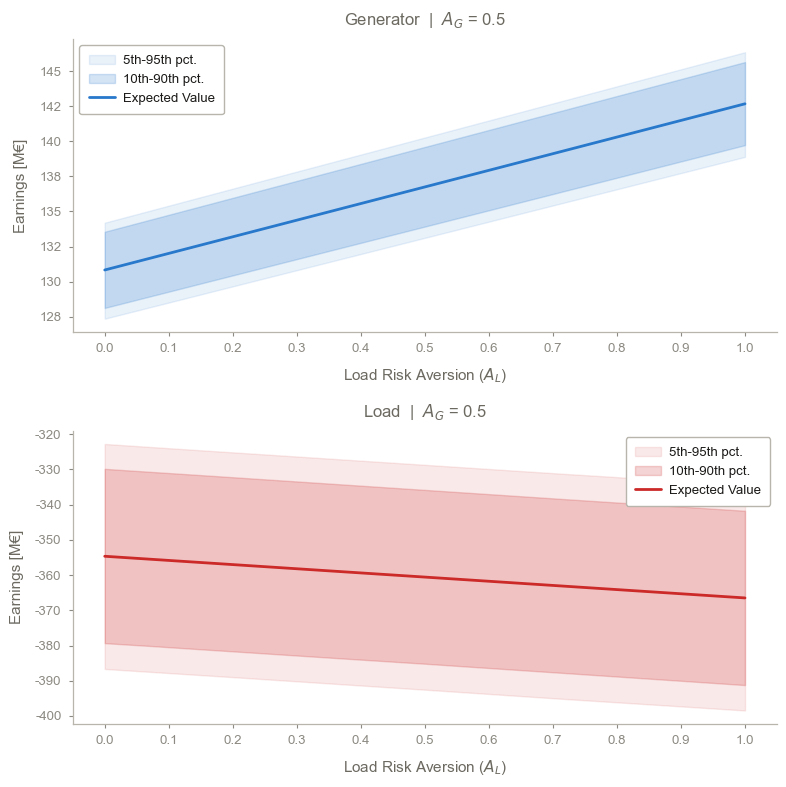

In [142]:
# ── PAP: stacked percentile bands
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=False)
fig.subplots_adjust( top=0.88)
plot_risk_profile(fig, axes, sum_pap_G, sum_pap_L, sum_pap_nc_G, sum_pap_nc_L,
                  mode="bands", contract_label="PAP contract",
                  disagree_G=dg_pap_G, disagree_L=dg_pap_L)
#figure_title(fig, f"PAP “ stacked percentile bands  ($A_G$ = {A_G_FIXED} fixed)")
save_figure(fig, "plots/pap_earnings/pap_earnings_stacked_bands")
save_panels(fig, axes, ["plots/pap_earnings/pap_earnings_stacked_bands_G",
                        "plots/pap_earnings/pap_earnings_stacked_bands_L"])
plt.show()

Saved plots/pap_earnings/pap_earnings_cvar5_lineplot.png
Saved plots/pap_earnings/pap_earnings_cvar5_lineplot_G.png
Saved plots/pap_earnings/pap_earnings_cvar5_lineplot_L.png


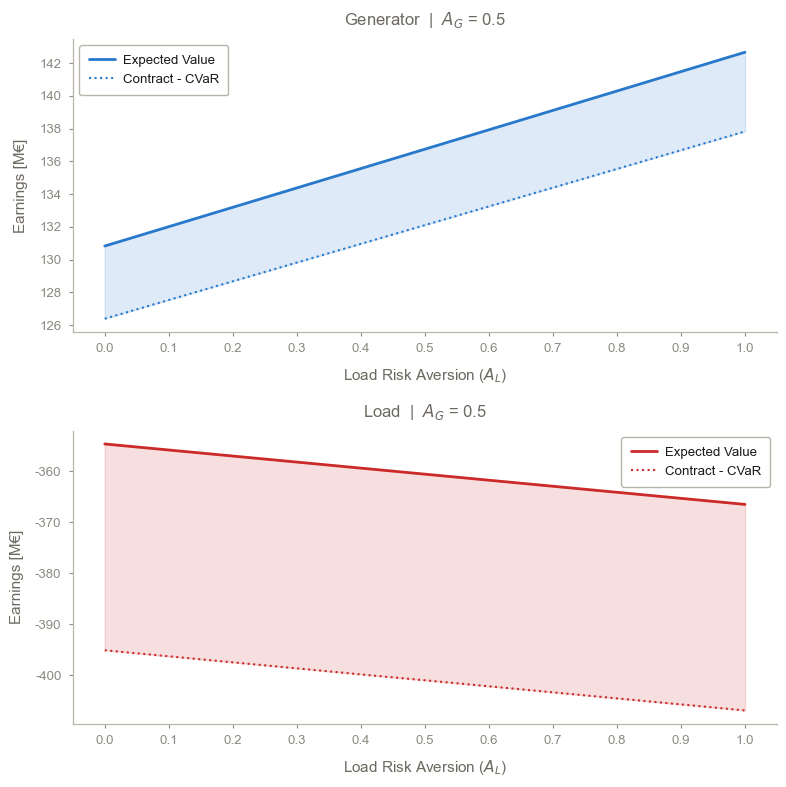

In [143]:
#PAP: CVaR vs mean 
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=False)
fig.subplots_adjust(hspace=0.12, top=0.88)
plot_risk_profile(fig, axes, sum_pap_G, sum_pap_L, sum_pap_nc_G, sum_pap_nc_L,
                  mode="cvar", contract_label="PAP contract",
                  disagree_G=dg_pap_G, disagree_L=dg_pap_L)
#figure_title(fig, f"PAP" CVaR{alpha_pct} vs mean earnings  ($A_G$ = {A_G_FIXED} fixed)")
save_figure(fig, f"plots/pap_earnings/pap_earnings_cvar{alpha_pct}_lineplot")
save_panels(fig, axes, [f"plots/pap_earnings/pap_earnings_cvar{alpha_pct}_lineplot_G",
                        f"plots/pap_earnings/pap_earnings_cvar{alpha_pct}_lineplot_L"])
plt.show()

Saved plots/contract_params_sensitivity/contract_params_sensitivity.png
Saved plots/contract_params_sensitivity/contract_params_sensitivity_Sa.png
Saved plots/contract_params_sensitivity/contract_params_sensitivity_Sb.png
Saved plots/contract_params_sensitivity/contract_params_sensitivity_Ma.png
Saved plots/contract_params_sensitivity/contract_params_sensitivity_Mb.png


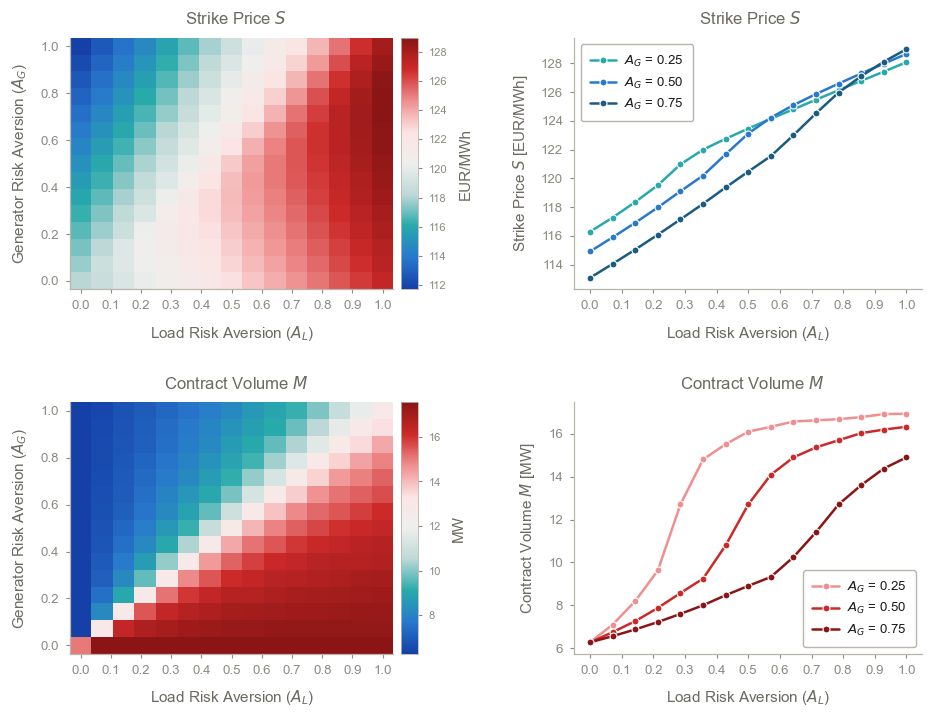

In [144]:
#Contract parameters: S and M sensitivity (heatmap + A_G slices)
# Produces a 2×2 figure:
#   (a) heatmap of S [EUR/MWh]    (b) line slices of S at 3 A_G values
#   (c) heatmap of M [MW]         (d) line slices of M at 3 A_G values

df_S = pd.read_csv(f"{BASE}/grid_S_EUR_MWh.csv", index_col=0)
df_M = pd.read_csv(f"{BASE}/grid_M_MWh_h.csv",   index_col=0)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_contract_params_grid(fig, axes,
    df_row0=df_S, df_row1=df_M,
    row_configs=[
        dict(heatmap_label="EUR/MWh",
             heatmap_panel="  Strike Price $S$",
             slice_label="Strike Price $S$ [EUR/MWh]",
             slice_panel=" Strike Price $S$",
             cmap=CMAP_DIVERGING, colors=COLORS_S),
        dict(heatmap_label="MW",
             heatmap_panel="  Contract Volume $M$",
             slice_label="Contract Volume $M$ [MW]",
             slice_panel="  Contract Volume $M$",
             cmap=CMAP_DIVERGING, colors=COLORS_M),
    ],
)
save_figure(fig, "plots/contract_params_sensitivity/contract_params_sensitivity")
save_panels(fig, axes.flat,
            ["plots/contract_params_sensitivity/contract_params_sensitivity_Sa",
             "plots/contract_params_sensitivity/contract_params_sensitivity_Sb",
             "plots/contract_params_sensitivity/contract_params_sensitivity_Ma",
             "plots/contract_params_sensitivity/contract_params_sensitivity_Mb"])
plt.show()

---
## PAP — Contract parameters: S and γ across risk aversion
*Requires `default_pap_risk_aversion` sweep. Run the setup cell first.*

Saved plots/pap_contract_params_sensitivity/pap_contract_params_sensitivity.png
Saved plots/pap_contract_params_sensitivity/pap_contract_params_sensitivity_Sa.png
Saved plots/pap_contract_params_sensitivity/pap_contract_params_sensitivity_Sb.png
Saved plots/pap_contract_params_sensitivity/pap_contract_params_sensitivity_gammaa.png
Saved plots/pap_contract_params_sensitivity/pap_contract_params_sensitivity_gammab.png


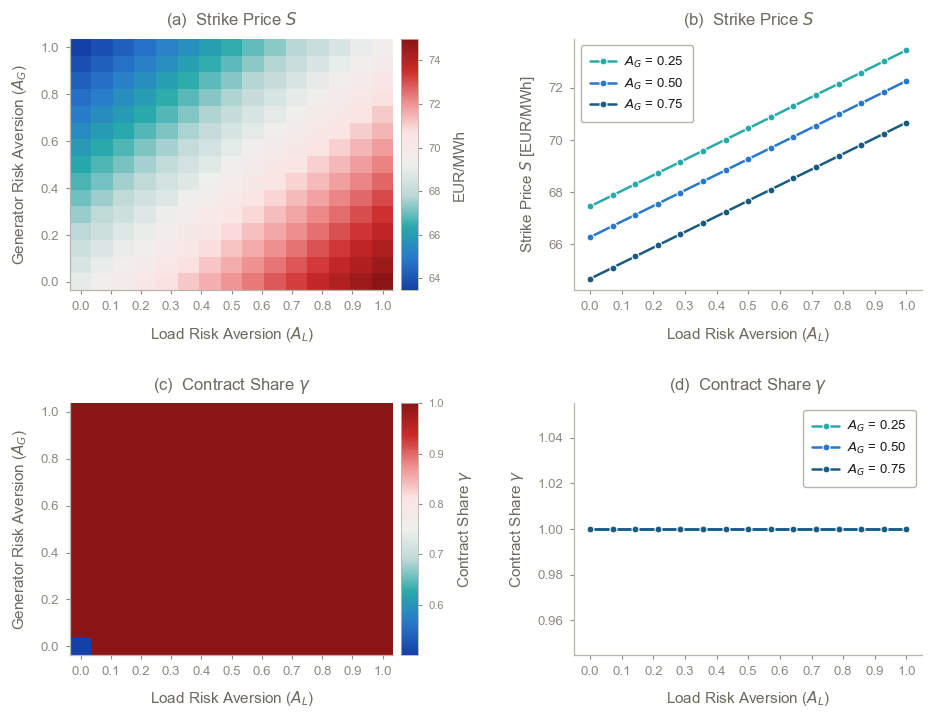

In [145]:
# ── PAP contract parameters: S and γ sensitivity (heatmap + A_G slices) ───────
# Produces a 2×2 figure:
#   (a) heatmap of S [EUR/MWh]    (b) line slices of S at 3 A_G values
#   (c) heatmap of γ              (d) line slices of γ at 3 A_G values

df_pap_S     = pd.read_csv(f"{BASE_PAP}/grid_S_EUR_MWh.csv", index_col=0)
df_pap_gamma = pd.read_csv(f"{BASE_PAP}/grid_gamma.csv",     index_col=0)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_contract_params_grid(fig, axes,
    df_row0=df_pap_S, df_row1=df_pap_gamma,
    row_configs=[
        dict(heatmap_label="EUR/MWh",
             heatmap_panel="(a)  Strike Price $S$",
             slice_label="Strike Price $S$ [EUR/MWh]",
             slice_panel="(b)  Strike Price $S$",
             cmap=CMAP_DIVERGING, colors=COLORS_S),
        dict(heatmap_label=r"Contract Share $\gamma$",
             heatmap_panel=r"(c)  Contract Share $\gamma$",
             slice_label=r"Contract Share $\gamma$",
             slice_panel=r"(d)  Contract Share $\gamma$",
             cmap=CMAP_DIVERGING, colors=COLORS_S),
    ],
)
save_figure(fig, "plots/pap_contract_params_sensitivity/pap_contract_params_sensitivity")
save_panels(fig, axes.flat,
            ["plots/pap_contract_params_sensitivity/pap_contract_params_sensitivity_Sa",
             "plots/pap_contract_params_sensitivity/pap_contract_params_sensitivity_Sb",
             "plots/pap_contract_params_sensitivity/pap_contract_params_sensitivity_gammaa",
             "plots/pap_contract_params_sensitivity/pap_contract_params_sensitivity_gammab"])
plt.show()

---
## Bargaining power - contract parameters
*Requires the `default_baseload_bargaining_power` sensitivity sweep (τ_L from 0 → 1, A_G = 0.5 fixed, A_L ∈ {0.25, 0.50, 0.75}). Run the setup cell first.*

Saved plots/baseload_bargaining_power_contract_params/baseload_bargaining_power_contract_params.png
Saved plots/baseload_bargaining_power_contract_params/baseload_bargaining_power_contract_params_S.png
Saved plots/baseload_bargaining_power_contract_params/baseload_bargaining_power_contract_params_M.png


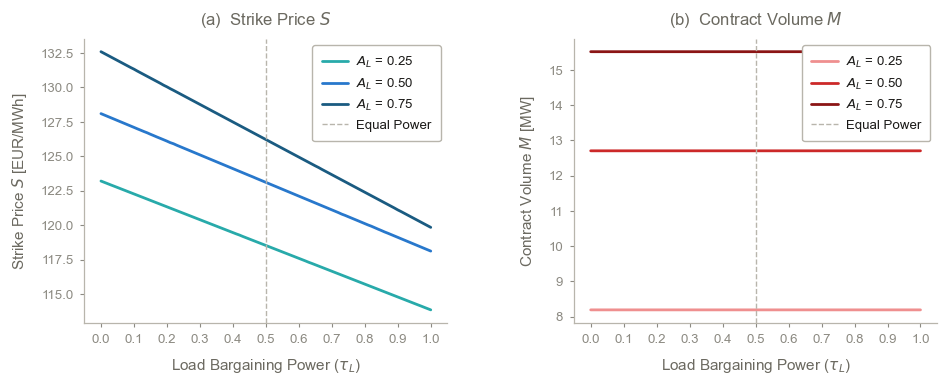

In [146]:
#Bargaining power: contract parameters S and M 
# Side-by-side panels: (a) strike price S [EUR/MWh], (b) contract volume M [MW].
# Three lines per panel — one per A_L value in {0.25, 0.50, 0.75}.
# Vertical dashed line marks the symmetric Nash solution (τ_L = 0.5).

BP_PATH     = "sensitivity/default_baseload_bargaining_power/results_combined.csv"
_AL_TARGETS = [0.25, 0.50, 0.75]
_AL_LABELS  = [r"$A_L$ = 0.25", r"$A_L$ = 0.50", r"$A_L$ = 0.75"]

df_bp = pd.read_csv(BP_PATH)
if "A_G" in df_bp.columns:
    df_bp = df_bp[np.isclose(df_bp["A_G"], A_G_FIXED)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.subplots_adjust(wspace=0.35, top=0.82)

for ax, metric, ylabel, colors, panel_label in [
    (axes[0], "S_EUR_MWh", "Strike Price $S$ [EUR/MWh]", COLORS_S, "(a)  Strike Price $S$"),
    (axes[1], "M_MWh_h",   "Contract Volume $M$ [MW]",   COLORS_M, "(b)  Contract Volume $M$"),
]:
    for al_target, color, lbl in zip(_AL_TARGETS, colors, _AL_LABELS):
        if "A_L" in df_bp.columns:
            sub = df_bp[np.isclose(df_bp["A_L"], al_target)].sort_values("tau_L")
        else:                                          # single-run fallback
            sub = df_bp.sort_values("tau_L")
            lbl = rf"$A_G$ = {A_G_FIXED}"
        ax.plot(sub["tau_L"], sub[metric], color=color, linewidth=2,
                label=lbl)

    ax.axvline(0.5, color=NEUTRAL["spine"], linewidth=1.0, linestyle="--",
               label="Equal Power")
    ax.set_xlabel(r"Load Bargaining Power ($\tau_L$)")
    ax.set_ylabel(ylabel)
    panel_subtitle(ax, panel_label)
    ax.set_xticks(_AL_TICKS)
    ax.legend(loc="best")

#figure_title(fig, rf"Contract parameters vs bargaining power  ($A_G$ = {A_G_FIXED} fixed)")
save_figure(fig, "plots/baseload_bargaining_power_contract_params/baseload_bargaining_power_contract_params")
save_panels(fig, axes, ["plots/baseload_bargaining_power_contract_params/baseload_bargaining_power_contract_params_S",
                        "plots/baseload_bargaining_power_contract_params/baseload_bargaining_power_contract_params_M"])
plt.show()


---
## PAP — Bargaining power — contract parameters
*Requires the `default_pap_bargaining_power` sensitivity sweep (τ_L from 0 → 1, A_G = 0.5 fixed, A_L ∈ {0.25, 0.50, 0.75}). Run the setup cell first.*

Saved plots/pap_bargaining_power_contract_params/pap_bargaining_power_contract_params.png
Saved plots/pap_bargaining_power_contract_params/pap_bargaining_power_contract_params_S.png
Saved plots/pap_bargaining_power_contract_params/pap_bargaining_power_contract_params_gamma.png


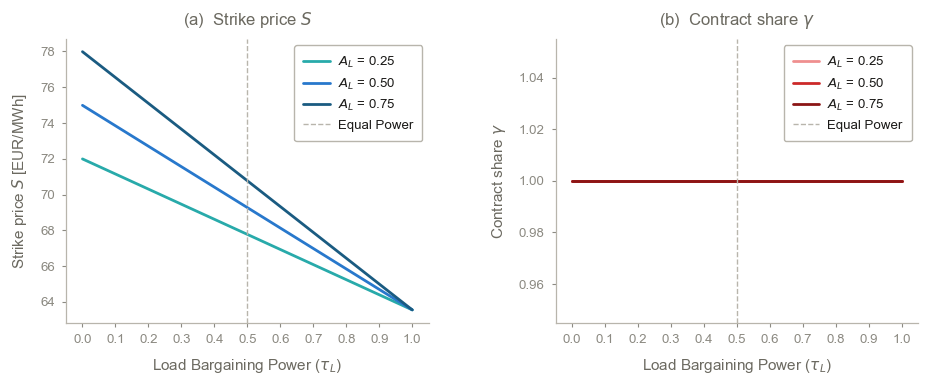

In [147]:
#PAP: Bargaining power - contract parameters S and gamma
# Side-by-side panels: (a) strike price S [EUR/MWh], (b) contract share γ.
# Three lines per panel - one per A_L value in {0.25, 0.50, 0.75}.
# Vertical dashed line marks the symmetric Nash solution (tau_L = 0.5).

BP_PAP_PATH = "sensitivity/default_pap_bargaining_power/results_combined.csv"
_AL_TARGETS = [0.25, 0.50, 0.75]
_AL_LABELS  = [r"$A_L$ = 0.25", r"$A_L$ = 0.50", r"$A_L$ = 0.75"]

df_bp_pap = pd.read_csv(BP_PAP_PATH)
if "A_G" in df_bp_pap.columns:
    df_bp_pap = df_bp_pap[np.isclose(df_bp_pap["A_G"], A_G_FIXED)]
df_bp_pap["gamma"] = df_bp_pap["gamma"].round(4)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.subplots_adjust(wspace=0.35, top=0.82)

for ax, metric, ylabel, colors, panel_label in [
    (axes[0], "S_EUR_MWh", "Strike price $S$ [EUR/MWh]",  COLORS_S, "(a)  Strike price $S$"),
    (axes[1], "gamma",     r"Contract share $\gamma$",      COLORS_M, r"(b)  Contract share $\gamma$"),
]:
    for al_target, color, lbl in zip(_AL_TARGETS, colors, _AL_LABELS):
        if "A_L" in df_bp_pap.columns:
            sub = df_bp_pap[np.isclose(df_bp_pap["A_L"], al_target)].sort_values("tau_L")
        else:
            sub = df_bp_pap.sort_values("tau_L")
            lbl = rf"$A_G$ = {A_G_FIXED}"
        ax.plot(sub["tau_L"], sub[metric], color=color, linewidth=2,
                label=lbl)

    ax.axvline(0.5, color=NEUTRAL["spine"], linewidth=1.0, linestyle="--",
               label="Equal Power")
    ax.set_xlabel(r"Load Bargaining Power ($\tau_L$)")
    ax.set_ylabel(ylabel)
    panel_subtitle(ax, panel_label)
    ax.set_xticks(_AL_TICKS)
    ax.legend(loc="best")

#figure_title(fig, rf"PAP — contract parameters vs bargaining power  ($A_G$ = {A_G_FIXED} fixed)")
save_figure(fig, "plots/pap_bargaining_power_contract_params/pap_bargaining_power_contract_params")
save_panels(fig, axes, ["plots/pap_bargaining_power_contract_params/pap_bargaining_power_contract_params_S",
                        "plots/pap_bargaining_power_contract_params/pap_bargaining_power_contract_params_gamma"])
plt.show()


---
## Contract size — strike price (baseload)
*Requires the `default_baseload_contract_size` sensitivity sweep (M from 0 → 30 MW, A_G = 0.5 fixed, τ_L ∈ {0.0, 0.5, 1.0}, A_L ∈ {0.25, 0.50, 0.75}). Run the setup cell first.*

Saved plots/baseload_contract_size/contract_size_S_AL025.png


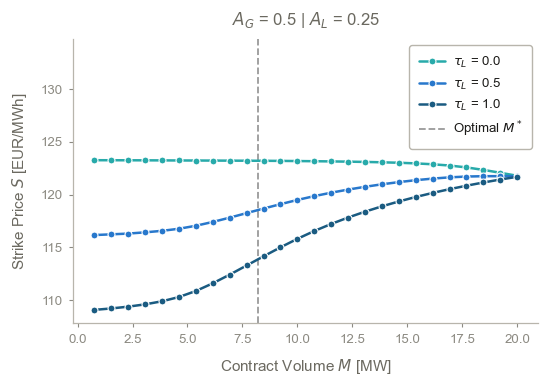

Saved → plots/baseload_contract_size/contract_size_S_AL025.png
Saved plots/baseload_contract_size/contract_size_S_AL050.png


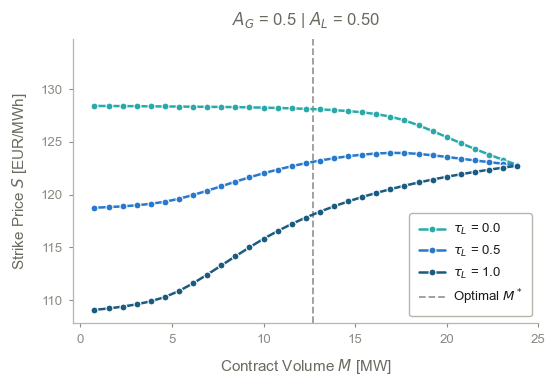

Saved → plots/baseload_contract_size/contract_size_S_AL050.png
Saved plots/baseload_contract_size/contract_size_S_AL075.png


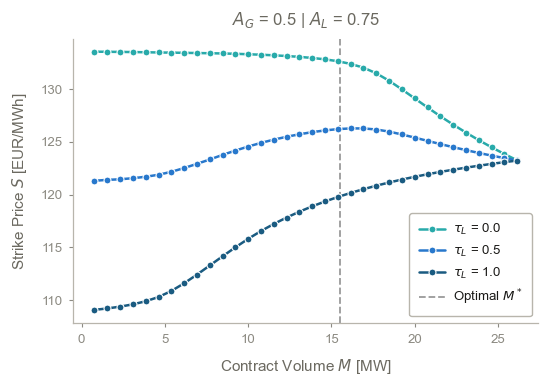

Saved → plots/baseload_contract_size/contract_size_S_AL075.png


In [154]:
#Contract size: strike price S vs M (baseload) 
# Three separate figures, one per A_L ∈ {0.25, 0.50, 0.75}.
# Each figure: 3 lines for tau_L ∈ {0.0, 0.5, 1.0}.
# A_G fixed at 0.5. Colors reuse COLORS_S from setup cell.

CS_PATH     = "sensitivity/default_baseload_contract_size/results_combined.csv"
_TAU_LABELS = [r"$\tau_L$ = 0.0", r"$\tau_L$ = 0.5", r"$\tau_L$ = 1.0"]
_TAU_VALS   = [0.0, 0.5, 1.0]
_AL_CONFIG  = [
    (0.25, "AL025", "0.25"),
    (0.50, "AL050", "0.50"),
    (0.75, "AL075", "0.75"),
]

df_cs = pd.read_csv(CS_PATH)
if "A_G" in df_cs.columns:
    df_cs = df_cs[np.isclose(df_cs["A_G"], A_G_FIXED)]
df_cs = df_cs[df_cs["M_MWh_h"] > 0]
_cs_y_pad = (df_cs["S_EUR_MWh"].max() - df_cs["S_EUR_MWh"].min()) * 0.05
_cs_ylim  = (df_cs["S_EUR_MWh"].min() - _cs_y_pad, df_cs["S_EUR_MWh"].max() + _cs_y_pad)

# Optimal (free-M) contract size per (A_G, A_L) — from the bargaining-power run, where
# M is a free decision variable (fix_contract_size=False) so its solved value is the optimum.
OPT_PATH = "sensitivity/default_baseload_bargaining_power/results_combined.csv"
_df_opt_cs = pd.read_csv(OPT_PATH)
if "A_G" in _df_opt_cs.columns:
    _df_opt_cs = _df_opt_cs[np.isclose(_df_opt_cs["A_G"], A_G_FIXED)]

for al_val, al_slug, al_str in _AL_CONFIG:
    sub_al = df_cs[np.isclose(df_cs["A_L"], al_val)]

    fig, ax = plt.subplots(figsize=(6, 4))
    fig.subplots_adjust(top=0.82)

    for tau, color, lbl in zip(_TAU_VALS, COLORS_S, _TAU_LABELS):
        sub = sub_al[np.isclose(sub_al["tau_L"], tau)].sort_values("M_MWh_h")
        ax.plot(sub["M_MWh_h"], sub["S_EUR_MWh"], color=color, linewidth=1.8,
                marker="o", markersize=5, markeredgecolor="white",
                markeredgewidth=0.8, label=lbl)

    # Optimal M for this (A_G, A_L) combo — one grey dashed vertical per panel
    # (constant across τ_L here, so a single line).
    _opt = _df_opt_cs[np.isclose(_df_opt_cs["A_L"], al_val)]
    if len(_opt):
        M_opt = _opt["M_MWh_h"].mean()
        ax.axvline(M_opt, color="grey", linestyle="--", linewidth=1.3,
                   alpha=0.8, zorder=1,label="Optimal $M^*$")

    ax.set_ylim(*_cs_ylim)
    ax.set_xlabel("Contract Volume $M$ [MW]")
    ax.set_ylabel("Strike Price $S$ [EUR/MWh]")
    ax.legend(loc="best")
    _style_panel_size(ax, rf"$A_G$ = {A_G_FIXED} | $A_L$ = {al_str}")
    #figure_title(fig,
    #    rf"Strike price vs contract size — baseload"
    #    rf"  ($A_L$ = {al_str},  $A_G$ = {A_G_FIXED})")
    fname = f"contract_size_S_{al_slug}"
    save_figure(fig, f"plots/baseload_contract_size/{fname}")
    plt.show()
    print(f"Saved → plots/baseload_contract_size/{fname}.png")


---
## Contract size — strike price (PAP)
*Requires the `default_pap_contract_size` sensitivity sweep (γ from 0 → 1, A_G = 0.5 fixed, τ_L ∈ {0.0, 0.5, 1.0}, A_L ∈ {0.25, 0.50, 0.75}). Run the setup cell first.*

<>:40: SyntaxWarning: invalid escape sequence '\g'
<>:40: SyntaxWarning: invalid escape sequence '\g'
C:\Users\AndersDHansen\AppData\Local\Temp\ipykernel_60012\638452195.py:40: SyntaxWarning: invalid escape sequence '\g'
  alpha=0.8, zorder=1, label="Optimal $\gamma^*$")


Saved plots/pap_contract_size/pap_contract_size_S_AL025.png


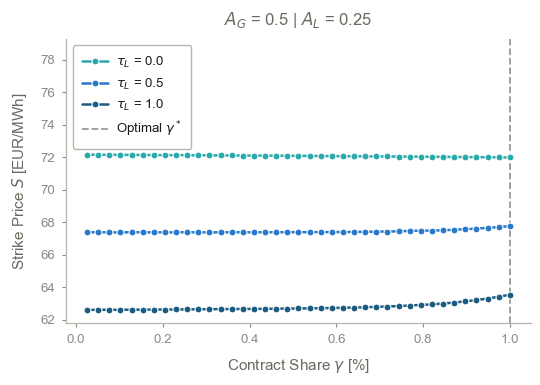

Saved → plots/pap_contract_size/pap_contract_size_S_AL025.png
Saved plots/pap_contract_size/pap_contract_size_S_AL050.png


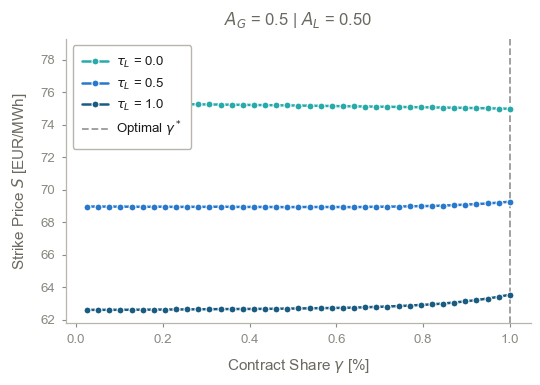

Saved → plots/pap_contract_size/pap_contract_size_S_AL050.png
Saved plots/pap_contract_size/pap_contract_size_S_AL075.png


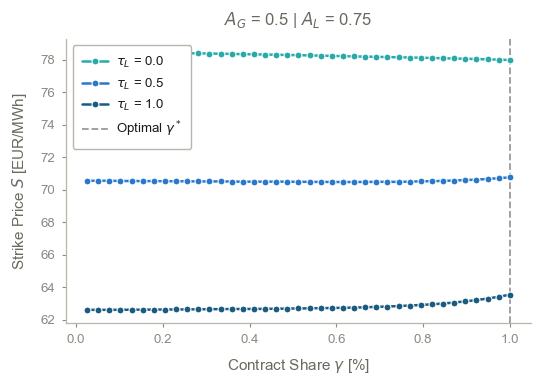

Saved → plots/pap_contract_size/pap_contract_size_S_AL075.png


In [155]:
# ── Contract size: strike price S vs γ (PAP) ──────────────────────────────────
# Three separate figures, one per A_L ∈ {0.25, 0.50, 0.75}.
# Each figure: 3 lines for tau_L ∈ {0.0, 0.5, 1.0}.
# A_G fixed at 0.5. Colors reuse COLORS_S from setup cell.

CS_PAP_PATH = "sensitivity/default_pap_contract_size/results_combined.csv"

df_cs_pap = pd.read_csv(CS_PAP_PATH)
if "A_G" in df_cs_pap.columns:
    df_cs_pap = df_cs_pap[np.isclose(df_cs_pap["A_G"], A_G_FIXED)]
df_cs_pap = df_cs_pap[df_cs_pap["gamma"] > 0.00]
_cs_pap_y_pad = (df_cs_pap["S_EUR_MWh"].max() - df_cs_pap["S_EUR_MWh"].min()) * 0.05
_cs_pap_ylim  = (df_cs_pap["S_EUR_MWh"].min() - _cs_pap_y_pad, df_cs_pap["S_EUR_MWh"].max() + _cs_pap_y_pad)

# Optimal (free-γ) contract share per (A_G, A_L) — from the bargaining-power run, where
# γ is a free decision variable (fix_contract_size=False) so its solved value is the optimum.
OPT_PAP_PATH = "sensitivity/default_pap_bargaining_power/results_combined.csv"
_df_opt_pap = pd.read_csv(OPT_PAP_PATH)
if "A_G" in _df_opt_pap.columns:
    _df_opt_pap = _df_opt_pap[np.isclose(_df_opt_pap["A_G"], A_G_FIXED)]

for al_val, al_slug, al_str in _AL_CONFIG:
    sub_al = df_cs_pap[np.isclose(df_cs_pap["A_L"], al_val)]

    fig, ax = plt.subplots(figsize=(6, 4))
    fig.subplots_adjust(top=0.82)

    for tau, color, lbl in zip(_TAU_VALS, COLORS_S, _TAU_LABELS):
        sub = sub_al[np.isclose(sub_al["tau_L"], tau)].sort_values("gamma")
        ax.plot(sub["gamma"], sub["S_EUR_MWh"], color=color, linewidth=1.8,
                marker="o", markersize=5, markeredgecolor="white",
                markeredgewidth=0.8, label=lbl)

    # Optimal γ for this (A_G, A_L) combo — one grey dashed vertical per panel
    # (constant across τ_L here, so a single line).
    _opt = _df_opt_pap[np.isclose(_df_opt_pap["A_L"], al_val)]
    if len(_opt):
        gamma_opt = _opt["gamma"].mean()
        ax.axvline(gamma_opt, color="grey", linestyle="--", linewidth=1.3,
                   alpha=0.8, zorder=1, label="Optimal $\gamma^*$")

    ax.set_ylim(*_cs_pap_ylim)
    ax.set_xlabel(r"Contract Share $\gamma$ [%]")
    ax.set_ylabel("Strike Price $S$ [EUR/MWh]")
    ax.legend(loc="best")
    _style_panel_size(ax, rf"$A_G$ = {A_G_FIXED} | $A_L$ = {al_str}")

    #figure_title(fig,
    #    rf"Strike price vs contract size — PAP"
    #    rf"  ($A_L$ = {al_str},  $A_G$ = {A_G_FIXED})")
    fname = f"pap_contract_size_S_{al_slug}"
    save_figure(fig, f"plots/pap_contract_size/{fname}")
    plt.show()
    print(f"Saved → plots/pap_contract_size/{fname}.png")


---
## Barter set — Nash bargaining utility set ($A_G$ = 0.50, $A_L$ = 0.50)

Utility-possibility curves swept over the contract volume at the two strike-price
extremes ($S^{\min}$, $S^{\max}$), the optimal-strike ($S^*$) curve, the disagreement
(no-contract) point at the origin, and the Nash optimum.

*Ported from `Code/Barter_Set.py`. Self-contained — reads the 2000-scenario inputs and the
`default_{pap,baseload}_risk_aversion` grids. Run the setup cell first.*

In [150]:
# ── Barter set (Nash bargaining): utility-possibility curves ──────────────────
# Ported from Code/Barter_Set.py, simplified for a single (A_G, A_L) configuration.
# Self-contained: scenario inputs are rebuilt from the 2000-scenario CSVs (K_*=0 in
# both configs ⇒ biased beliefs == raw scenarios); the optimal contract and the
# disagreement point are read from the sensitivity grids. Both experiment configs use
# discount=false, so all discount factors are 1.
#
# The shaded barter set is the triangle bounded by the IR axes and the line through the
# two extreme-strike curves at the Nash-optimal contract volume M_opt (MR on S^min, MU on
# S^max). At a fixed contract volume the strike traces the Lemma-2 frontier (U_L linear in
# U_G), so the MR-MU segment is exactly that frontier line and the Nash optimum lies on it.
# Verified: reproduces grid_disagreement_* and grid_utility_* at A_G=A_L=0.5 exactly; the
# M_opt line passes through the Nash optimum (baseload (0,22.22)/(22.22,0)).

_BS_AG, _BS_AL = 0.5, 0.5
_BS_ALPHA      = 0.95                       # CVaR confidence (worst 5%) — matches the model
_BS_SMIN, _BS_SMAX = 0.040, 0.200           # strike bounds [internal kEUR/MWh = EUR/GWh×1e-3]
_BS_SCEN  = "../data/processed/scenarios_reduced_2000"
_BS_SFX   = "scenarios_reduced_20y_2000s"


def _bs_cvar_left(x, prob, alpha):
    """Left-tail CVaR: expected value over the worst (1-alpha) probability mass."""
    tail = 1.0 - alpha
    order = np.argsort(x)
    xs, ps = x[order], prob[order]
    prev_cum = np.concatenate([[0.0], np.cumsum(ps)[:-1]])
    w = np.minimum(ps, np.maximum(0.0, tail - prev_cum))
    return float((w * xs).sum() / tail)


def _bs_scen(kind):
    return pd.read_csv(f"{_BS_SCEN}/{kind}_{_BS_SFX}.csv", index_col=0).to_numpy()

# Scenario arrays (years × scenarios) and probabilities.
_bs_price   = _bs_scen("price")
_bs_prod    = _bs_scen("production")
_bs_cr      = _bs_scen("capture_rate")
_bs_load    = _bs_scen("load")
_bs_loadcr  = _bs_scen("load_capture_rate")
_bs_prob    = pd.read_csv(f"{_BS_SCEN}/probabilities_{_BS_SFX}.csv")["Probability"].to_numpy().astype(float)
_bs_prob   /= _bs_prob.sum()
_bs_disc    = np.ones((_bs_price.shape[0], 1))      # discount=false ⇒ unit discount factors


def _bs_earnings_G(ct, S, vol):
    """Per-scenario generator earnings. PAP: vol=γ∈[0,1]. Baseload: vol=M [GWh/yr]."""
    if ct == "pap":
        return (_bs_disc * ((1 - vol) * _bs_prod * _bs_price * _bs_cr + vol * _bs_prod * S)).sum(0)
    return (_bs_disc * _bs_cr * _bs_price * _bs_prod).sum(0) + (_bs_disc * vol * (S - _bs_price)).sum(0)


def _bs_earnings_L(ct, S, vol):
    """Per-scenario load earnings (net cost, typically negative)."""
    base = (_bs_disc * (-_bs_loadcr * _bs_price * _bs_load)).sum(0)
    if ct == "pap":
        return base + (_bs_disc * vol * _bs_prod * (_bs_price * _bs_cr - S)).sum(0)
    return base + (_bs_disc * vol * (_bs_price - S)).sum(0)


def _bs_U(earn, A):
    """Risk-averse utility: (1-A)·E[earnings] + A·CVaR_left(earnings)."""
    return (1 - A) * (_bs_prob * earn).sum() + A * _bs_cvar_left(earn, _bs_prob, _BS_ALPHA)

_bs_UG = lambda ct, S, vol: _bs_U(_bs_earnings_G(ct, S, vol), _BS_AG)
_bs_UL = lambda ct, S, vol: _bs_U(_bs_earnings_L(ct, S, vol), _BS_AL)


def _bs_grid_at(ct, name, ag=_BS_AG, al=_BS_AL):
    """Read a sensitivity grid pivot (index=A_G, columns=A_L) at the (ag, al) cell."""
    df = pd.read_csv(f"sensitivity/default_{ct}_risk_aversion/{name}.csv", index_col=0)
    df.index, df.columns = df.index.astype(float), df.columns.astype(float)
    i = int(np.argmin(np.abs(df.index.values - ag)))
    j = int(np.argmin(np.abs(df.columns.values - al)))
    return float(df.iloc[i, j])


def barter_set_curves(ct, n=300):
    """Build the two extreme-strike utility curves, their optimal-contract (M_opt)
    points, the bargaining-frontier line through them, the slope-based barter-set
    triangle, and the Nash optimum — normalised by the disagreement (no-contract) utility."""
    if ct == "pap":
        m_space = np.linspace(0.0, 1.0, n)                       # contract share γ
        vol_opt = _bs_grid_at(ct, "grid_gamma")
    else:
        c_max = 30 * 8760 * 1e-3                                 # contract bound [GWh/yr]
        m_space = np.linspace(0.0, c_max, n)                     # contract volume M
        vol_opt = _bs_grid_at(ct, "grid_M_GWh_year")
    S_opt = _bs_grid_at(ct, "grid_S_EUR_MWh") * 1e-3            # EUR/MWh → internal units

    zeta_G, zeta_L = _bs_UG(ct, _BS_SMIN, 0.0), _bs_UL(ct, _BS_SMIN, 0.0)   # = disagreement
    curve = lambda S: np.array([[_bs_UG(ct, S, m) - zeta_G, _bs_UL(ct, S, m) - zeta_L] for m in m_space])
    V_min, V_max = curve(_BS_SMIN), curve(_BS_SMAX)
    opt_pt = np.array([_bs_UG(ct, S_opt, vol_opt) - zeta_G, _bs_UL(ct, S_opt, vol_opt) - zeta_L])

    # Optimal-contract point on each extreme-strike curve: the locus point at the Nash-optimal
    # contract volume M_opt. At a fixed contract the strike traces the Lemma-2 frontier line, so
    # the MR-MU segment is exactly that frontier and the Nash optimum lies on it.
    idx_opt = int(np.argmin(np.abs(m_space - vol_opt)))
    MR = V_min[idx_opt]                                          # on S^min curve at M_opt
    MU = V_max[idx_opt]                                          # on S^max curve at M_opt

    # Barter set: triangle bounded by the IR axes and the line through MR and MU.
    slope = (MU[1] - MR[1]) / (MU[0] - MR[0])
    b = MR[1] - slope * MR[0]
    triangle = np.array([[0.0, 0.0], [0.0, b], [-b / slope, 0.0]])

    return dict(
        V_min=V_min, V_max=V_max, MR=MR, MU=MU, triangle=triangle, opt_pt=opt_pt,
        slope=slope, zeta=(zeta_G, zeta_L), S_opt_mwh=S_opt * 1e3, vol_opt=vol_opt,
    )


def plot_barter_set(ct, title, vol_unit, view="zoom", zoom_to_opt=False):
    """view='zoom' frames the barter-set triangle; view='full' shows the entire
    extreme-strike curves with the M_opt points and the line drawn between them.
    zoom_to_opt (full view only) reframes the axes onto the optimal-contract zone
    (MR, MU and the Nash optimum) instead of autoscaling to the whole curves."""
    d = barter_set_curves(ct)
    Vmin, Vmax, MR, MU, tri, opt = d["V_min"], d["V_max"], d["MR"], d["MU"], d["triangle"], d["opt_pt"]

    fig, ax = plt.subplots(figsize=(7, 6.5))
    fig.subplots_adjust(top=0.88)

    ax.fill(tri[:, 0], tri[:, 1], color=C_G, alpha=0.15, lw=0, label="Barter set")
    ax.plot(Vmin[:, 0], Vmin[:, 1], color=C_G, lw=2.2, label=r"$S^{\min}$ = 40 EUR/MWh")
    ax.plot(Vmax[:, 0], Vmax[:, 1], color=C_L, lw=2.2, label=r"$S^{\max}$ = 200 EUR/MWh")
    # Bargaining frontier: the line through the two curves at the optimal contract M_opt (extended to the axes).
    ax.plot([MR[0], MU[0]], [MR[1], MU[1]], color=NEUTRAL["label"], lw=1.6, ls="--",
            )#label=rf"Bargaining frontier (slope = {d['slope']:.2f})")
    vol_disp = d["vol_opt"] * 1e3 / 8760 if ct != "pap" else d["vol_opt"]  # GWh/yr -> MWh/h for baseload
    ax.scatter([MR[0], MU[0]], [MR[1], MU[1]], color=MULTILINE_PALETTE["dark_green"], s=55, zorder=5,
               label=(r"$\gamma^*$ = {:.2f}".format(vol_disp) if ct == "pap"
                      else "$M^*$ = {:.2f} {}".format(vol_disp, vol_unit)))

    ax.axvline(0, color=NEUTRAL["spine"], ls="--", lw=1.0, alpha=0.7)
    ax.axhline(0, color=NEUTRAL["spine"], ls="--", lw=1.0, alpha=0.7)
    ax.scatter(0, 0, color=NEUTRAL["label"], s=90, zorder=5, label="Disagreement point")
    ax.scatter(*opt, color=C_G_dark, s=200, marker="*", zorder=6,
               edgecolor="white", linewidth=1.0,
               label=rf"Nash Solution")

    if view == "zoom":
        # Frame the barter-set triangle; the extreme-strike curves extend beyond and clip.
        lim = float(max(tri[1, 1], tri[2, 0]))
        ax.set_xlim(-0.18 * lim, 1.12 * lim)
        ax.set_ylim(-0.18 * lim, 1.12 * lim)
        suffix, legend_loc = "", "upper right"
    elif zoom_to_opt:
        # Full curves, but framed tightly on the optimal-contract zone (MR, MU, Nash optimum);
        # the curves' M > M_opt tails extend beyond the window and clip.
        pts = np.array([MR, MU, opt])
        xpad = 0.15 * (np.ptp(pts[:, 0]) or 1.0)
        ypad = 0.15 * (np.ptp(pts[:, 1]) or 1.0)
        ax.set_xlim(pts[:, 0].min() - xpad, pts[:, 0].max() + xpad)
        ax.set_ylim(pts[:, 1].min() - ypad, pts[:, 1].max() + ypad)
        suffix, legend_loc = "_full", "best"
    else:
        ax.margins(0.05)                                         # autoscale to the full curves
        suffix, legend_loc = "_full", "best"

    ax.set_xlabel(r"Generator Utility $-$ Disagreement  [M€]")
    ax.set_ylabel(r"Load Utility $-$ Disagreement  [M€]")
    panel_subtitle(ax, rf"$A_G$ = {_BS_AG:.2f},  $A_L$ = {_BS_AL:.2f}")
    #figure_title(fig, title)
    ax.legend(loc=legend_loc, fontsize=9)
    save_figure(fig, f"plots/barter_set/barter_set_{ct}{suffix}")
    plt.show()
    print(f"{ct} [{view}]: S* = {d['S_opt_mwh']:.2f} EUR/MWh,  contract = {d['vol_opt']:.4g},  slope = {d['slope']:.4f},  "
          f"disagreement (ζ_G, ζ_L) = ({d['zeta'][0]:.2f}, {d['zeta'][1]:.2f}) M€,  "
          f"Nash optimum (Δ_G, Δ_L) = ({opt[0]:.3f}, {opt[1]:.3f}) M€")

Saved plots/barter_set/barter_set_pap.png


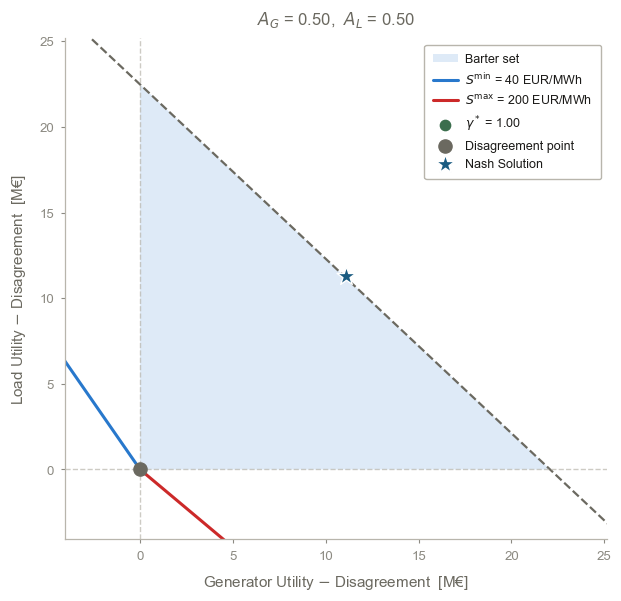

pap [zoom]: S* = 69.27 EUR/MWh,  contract = 1,  slope = -1.0179,  disagreement (ζ_G, ζ_L) = (123.33, -392.03) M€,  Nash optimum (Δ_G, Δ_L) = (11.097, 11.281) M€
Saved plots/barter_set/barter_set_pap_full.png


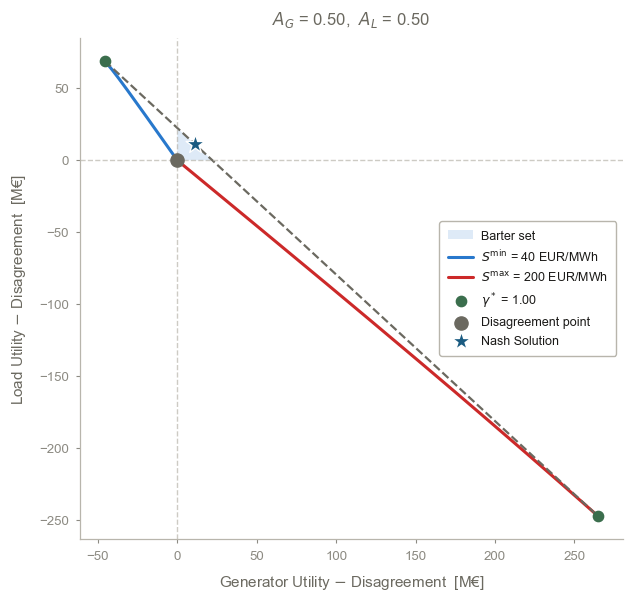

pap [full]: S* = 69.27 EUR/MWh,  contract = 1,  slope = -1.0179,  disagreement (ζ_G, ζ_L) = (123.33, -392.03) M€,  Nash optimum (Δ_G, Δ_L) = (11.097, 11.281) M€


In [151]:
# Barter set — PAP contract (zoomed to the triangle, then full curves)
plot_barter_set("pap", "Barter set - PAP contract", vol_unit="%", view="zoom")
plot_barter_set("pap", "Barter set — PAP contract (full curves)", vol_unit="%", view="full")

Saved plots/barter_set/barter_set_baseload.png


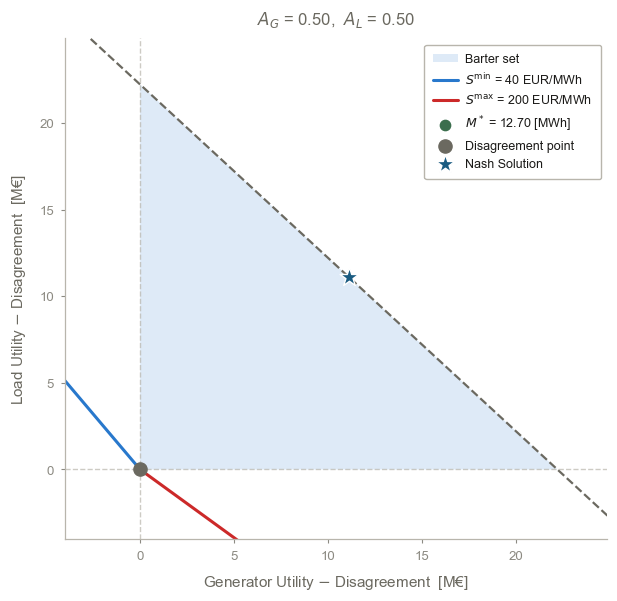

baseload [zoom]: S* = 123.11 EUR/MWh,  contract = 111.3,  slope = -1.0000,  disagreement (ζ_G, ζ_L) = (123.33, -392.03) M€,  Nash optimum (Δ_G, Δ_L) = (11.112, 11.112) M€
Saved plots/barter_set/barter_set_baseload_full.png


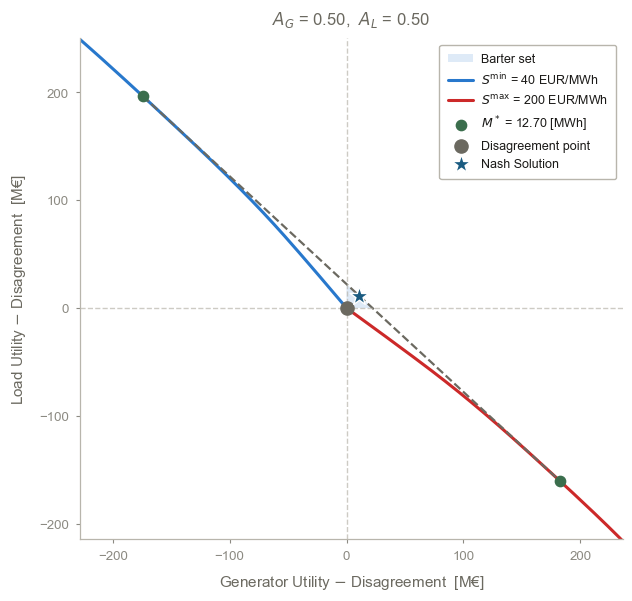

baseload [full]: S* = 123.11 EUR/MWh,  contract = 111.3,  slope = -1.0000,  disagreement (ζ_G, ζ_L) = (123.33, -392.03) M€,  Nash optimum (Δ_G, Δ_L) = (11.112, 11.112) M€


In [152]:
# Barter set — Baseload contract (zoomed to the triangle, then full curves)
plot_barter_set("baseload", "Barter set - Baseload contract", vol_unit="[MWh]", view="zoom")
plot_barter_set("baseload", "Barter set - Baseload contract (full curves)", vol_unit="[MWh]", view="full", zoom_to_opt=True)

Saved plots/baseload_load_risk_aversion/strike_volume_Mvar.png
Saved plots/baseload_load_risk_aversion/strike_volume_Mvar_strike.png
Saved plots/baseload_load_risk_aversion/strike_volume_Mvar_volume.png


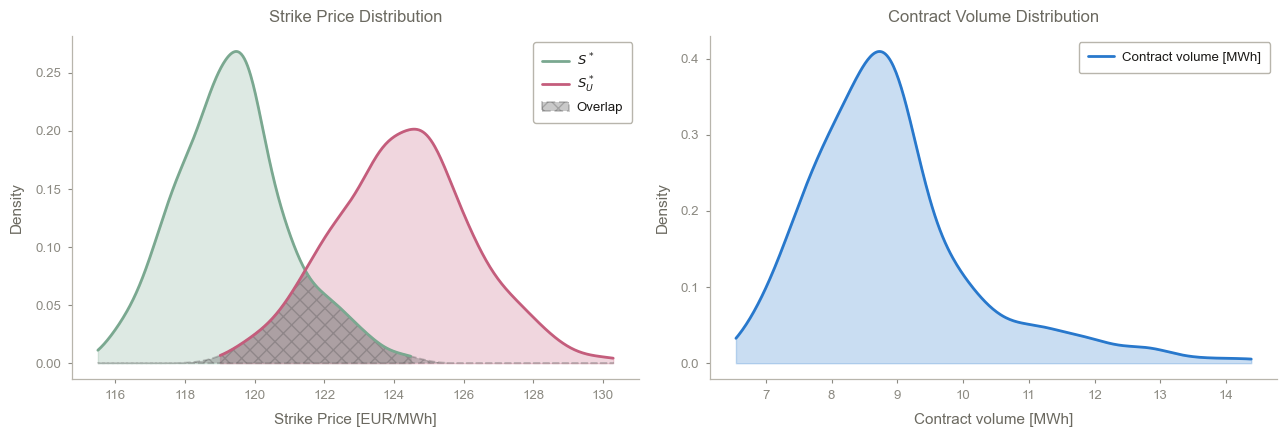

Saved plots/baseload_load_risk_aversion/strike_volume_Mfix.png
Saved plots/baseload_load_risk_aversion/strike_volume_Mfix_strike.png
Saved plots/baseload_load_risk_aversion/strike_volume_Mfix_volume.png


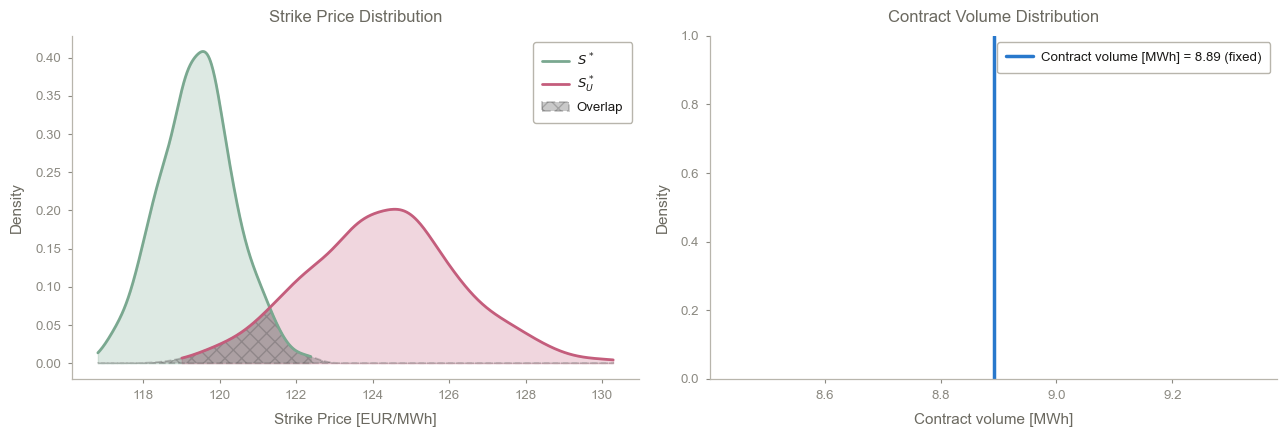

Saved plots/pap_load_risk_aversion/strike_volume.png
Saved plots/pap_load_risk_aversion/strike_volume_strike.png
Saved plots/pap_load_risk_aversion/strike_volume_volume.png


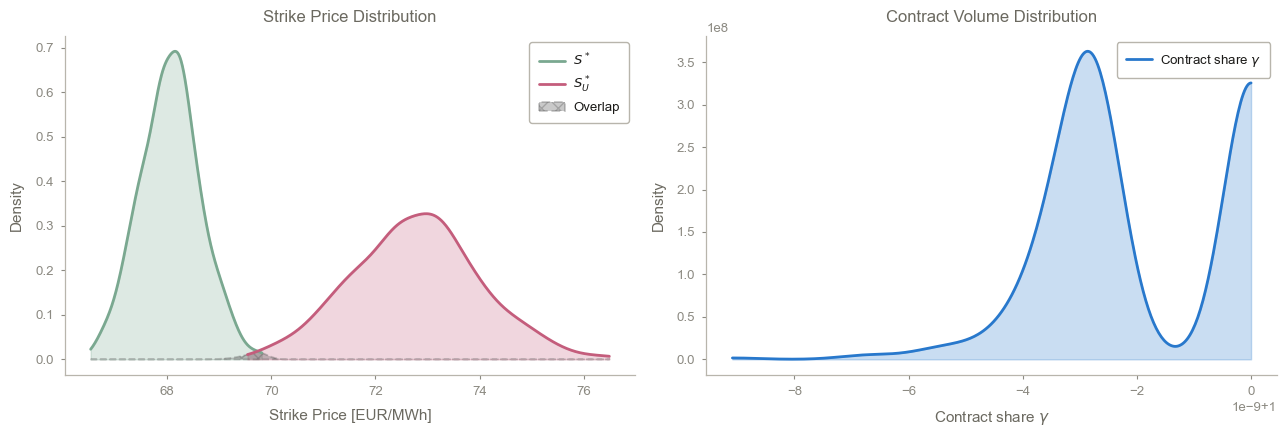

In [153]:
# ── Load risk aversion: A_L ~ N(0.3, 0.1) at fixed A_G — strike & volume distributions ──
# Reads the load_risk_aversion sweep CSVs and plots KDEs of S*, S_U* (+ S_R* line) and the
# contract volume, with 5–95% inter-percentile bands. Baseload: M-variable & M-fixed; PAP: gamma.
# Saves the 2-panel figure plus each panel on its own.
from scipy.stats import gaussian_kde

CI_LO, CI_HI = 5, 95

def _dist(ax, s, color, label, band=None):
    """KDE fill (or a vertical line if degenerate, e.g. M fixed), optional inter-percentile band."""
    s = s.dropna()
    if s.nunique() <= 1:
        ax.axvline(s.iloc[0], color=color, lw=2.5, label=f"{label} = {s.iloc[0]:.2f} (fixed)")
        return
    kde = gaussian_kde(s.to_numpy())
    x = np.linspace(s.min(), s.max(), 400)
    y = kde(x)
    ax.plot(x, y, color=color, lw=2, label=label)
    ax.fill_between(x, y, color=color, alpha=0.25)
    #if band is not None:
    #    lo, hi = np.percentile(s, [CI_LO, CI_HI])
    #    ax.axvspan(lo, hi, color=band, alpha=0.15,
    #               label=f"{CI_HI - CI_LO}% CI [{lo:.1f}, {hi:.1f}]")

def _overlap(ax, s1, s2, color="0.3", label="Overlap"):
    """Shade where two KDEs overlap (min of the densities), dashed outline."""
    s1, s2 = s1.dropna(), s2.dropna()
    if s1.nunique() <= 1 or s2.nunique() <= 1:
        return
    x = np.linspace(min(s1.min(), s2.min()), max(s1.max(), s2.max()), 400)
    y = np.minimum(gaussian_kde(s1.to_numpy())(x), gaussian_kde(s2.to_numpy())(x))
    ax.fill_between(x, y, color=color, alpha=0.3, hatch="xx",
                    edgecolor=color, linestyle="--", linewidth=1.3, label=label)

def plot_load_risk_aversion(df, vol_col, vol_label, title, fname):
    df = df[df["feasible"]].copy()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    _dist(ax1, df["S_EUR_MWh"], LINE_PALETTE["sage"], r"$S^*$", band=LINE_PALETTE["sage"])
    _dist(ax1, df["SU_star"],   LINE_PALETTE["pink"], r"$S_U^*$")
    _overlap(ax1, df["S_EUR_MWh"], df["SU_star"])
    #sr = df["SR_star"].mean()
    #ax1.axvline(sr, color=LINE_PALETTE["blue"], ls="--", lw=2, label=rf"$S_R^*$ = {sr:.1f}")
    ax1.set_xlabel("Strike Price [EUR/MWh]"); ax1.set_ylabel("Density")
    ax1.legend(); panel_subtitle(ax1, "Strike Price Distribution")

    _dist(ax2, df[vol_col], LINE_PALETTE["blue"], vol_label, band=LINE_PALETTE["mustard"])
    ax2.set_xlabel(vol_label); ax2.set_ylabel("Density")
    ax2.legend(); panel_subtitle(ax2, "Contract Volume Distribution")

    #figure_title(fig, title)
    fig.tight_layout()
    save_figure(fig, fname)
    save_panels(fig, (ax1, ax2), [f"{fname}_strike", f"{fname}_volume"])
    plt.show()

_LRA = "sensitivity/{}_load_risk_aversion"

plot_load_risk_aversion(
    pd.read_csv(f"{_LRA.format('default_baseload')}/results_Mvar.csv"),
    "M_MWh_h", "Contract volume [MWh]",
    r"Load risk aversion — baseload ($M$ optimised)",
    "plots/baseload_load_risk_aversion/strike_volume_Mvar")

plot_load_risk_aversion(
    pd.read_csv(f"{_LRA.format('default_baseload')}/results_Mfix.csv"),
    "M_MWh_h", "Contract volume [MWh]",
    r"Load risk aversion — baseload ($M$ fixed at mean optimal)",
    "plots/baseload_load_risk_aversion/strike_volume_Mfix")

plot_load_risk_aversion(
    pd.read_csv(f"{_LRA.format('default_pap')}/results.csv"),
    "gamma", r"Contract share $\gamma$",
    "Load risk aversion — PAP",
    "plots/pap_load_risk_aversion/strike_volume")
